## Aid Received Analysis

This notebook explores and analyses the aid entering Gaza since the beginning of the genocide in Gaza. It also examines whether the volume and composition of humanitarian aid is primarily constrained by border access rather than supply availability.

The aid_events mart is used for analysis, which is derived from: https://data.humdata.org/dataset/state-of-palestine-gaza-aid-truck-data

Data is aggregated weekly with a four week moving average applied to reduce daily volatility and smooth visualisations.

This notebook is currently a work in progress.

### Hypothesis

Based on reports that aid trucks frequently queue at border crossings awaiting clearance, it is hypothesised that border access acts as a limiting factor for incoming aid.

The following specific hypotheses are tested:

1. Total aid volume increases during ceasefires.

Weekly truck totals are expected to be higher during periods of ceasefire relative to active conflict, given the significant logistical difficulties that hostilities create for aid deliveries.

2. Food and water to be prioritised, followed by shelter materials and other important items.

Items critical for immediate survival are expected to dominate aid deliveries (food, water), followed by shelter materials (tents, bedding), and then hygiene items and clothing.

Shelter materials are likely to be key, following food and water, due to the widespread destruction of civilian infrastructure and the displacement of the vast majority of Gaza's population. Medical items are expected to fluctuate depending on the scale of civilian injuries and disease outbreaks.

3. Medical supply deliveries to increase relative to other aid types during periods of greater hostility.

Whilst total aid deliveries are likely to be lower, medical supplies are expected to feature in a higher proportion of deliveries. Greater hostilities are likely to result in greater civilian casualties which will require significantly more medical supplies.

4. Aid composition skews towards non-perishables during periods of restricted access.

During periods of reduced aid, trucks are likely to spend extended waiting times at border crossings. This could result in non-perishables being prioritised, since they are more likely to survive the potentially long waiting times at the borders.


#### Ceasefires occurred on the following dates:

- 24th November 2023 to 1st December 2023
- 19th January 2025 to 17th March 2025
- 3rd October 2025 to present

### Data considerations and measurement limitations

A key methodological decision in this analysis is the use of number_of_trucks as the primary metric rather than the quantity field.

Although the data contains a quantity measure, it is recorded in multiple incompatible units (e.g. Pallets, Metric Ton, Ton, Piece, Cartons, Vehicles, etc.). While pallets represent the majority of entries, the presence of numerous other unit types prevent meaningful aggregation without introducing strong assumptions or unit conversions.

Although truck counts do not represent exact aid volume, they provide insight into distribution and a standardised, comparable measure across all aid events. The distribution of units in the dataset is shown below.

In [103]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


con = duckdb.connect("../dev.duckdb")

con.execute("""
SELECT units, SUM(quantity)::INT AS total_quantity
FROM main_mart.aid_events
GROUP BY units
ORDER BY SUM(quantity) DESC
""").df()

,units,total_quantity
0,Pallets,825933
1,MT,97056
2,Piece,73415
3,CTN,7920
4,Ton,6117
5,Truck,3871
6,NaN,3537
7,EACH,786
8,Tents,30
9,Vehicles,21


### Cargo category distribution

The table below shows total aid trucks by cargo category.

In [104]:
con.execute("""
SELECT
    cargo_category,
    COUNT(DISTINCT date_id) as days_with_deliveries,
    SUM(number_of_trucks) as total_trucks,
    MIN(full_date) as first_delivery,
    MAX(full_date) as last_delivery
FROM main_mart.aid_events
GROUP BY cargo_category
ORDER BY total_trucks DESC
""").df()

,cargo_category,days_with_deliveries,total_trucks,first_delivery,last_delivery
0,Food Items,432,38390.0,2023-10-21,2025-01-16
1,Non-Food Items,382,8165.0,2023-10-23,2025-01-13
2,Mixed Items,292,1812.0,2023-10-22,2025-01-13
3,Medical Supplies,270,1692.0,2023-10-21,2025-01-05


### Monthly trucks per cargo category

To analyse trends in aid deliveries over time per cargo category, the data is aggregated to a monthly level to reduce daily volatility and to smooth the spikes and troughs.

A key thing to note is that this looks at the number of trucks that contain categories of items, which may not correspond to the exact volume of aid that is entering.

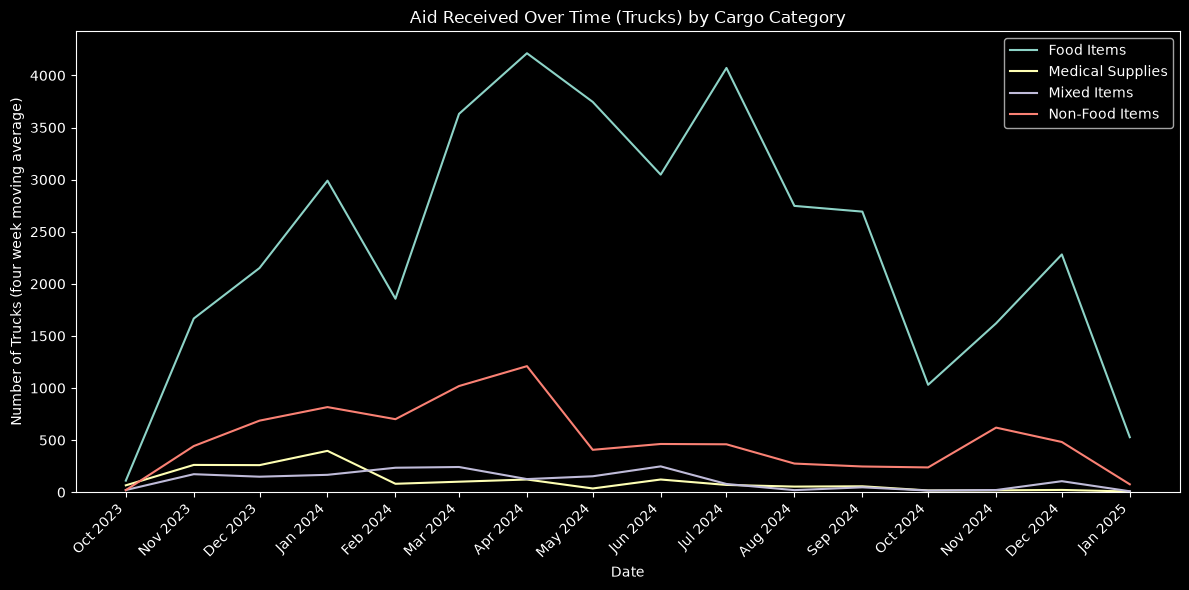

In [105]:
df = con.execute("""
SELECT
    year,
    month,
    month_start,
    cargo_category,
    monthly_truck_count
FROM main_mart.monthly_aid_by_category
ORDER BY year, month
""").df()

df_pivot = df.pivot(
    index="month_start",
    columns="cargo_category",
    values="monthly_truck_count"
).fillna(0).sort_index()

plt.figure(figsize=(12,6))

for column in df_pivot.columns:
    plt.plot(df_pivot.index, df_pivot[column], label=column)

plt.ylim(bottom=0)
plt.xlabel("Date")
plt.ylabel("Number of Trucks (four week moving average)")
plt.title("Aid Received Over Time (Trucks) by Cargo Category")
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


Food items consistently dominated aid deliveries throughout the entire period, which was expected due to being critical for survival. Non-food items - which include mattresses, blankets, tents, hygiene kits and diapers - were also relatively highly prioritised.

### Trucks per week during ceasefires vs during hostilites



In [106]:
con.execute("""
    WITH trucks_per_week_per_category AS (
        SELECT
            cargo_category,
            year,
            week_of_year,
            SUM(CASE WHEN is_ceasefire = 1 THEN 1 ELSE 0 END) >= 4 AS ceasefire_week,
            SUM(number_of_trucks) AS weekly_trucks
        FROM main_mart.aid_events
        GROUP BY cargo_category, year, week_of_year
    ),

    weekly_averages AS (
        SELECT
            cargo_category,
            ROUND(AVG(CASE WHEN ceasefire_week = 1 THEN weekly_trucks ELSE NULL END), 2) AS ceasefires,
            ROUND(AVG(CASE WHEN ceasefire_week = 0 THEN weekly_trucks ELSE NULL END), 2) AS conflicts
        FROM trucks_per_week_per_category
        GROUP BY cargo_category
    )

    SELECT * FROM (
        SELECT * FROM weekly_averages

        UNION ALL

        SELECT
            'Total',
            SUM(ceasefires),
            SUM(conflicts)
        FROM weekly_averages
    )
    ORDER BY
        CASE WHEN cargo_category = 'Total' THEN 0 ELSE (ceasefires + conflicts) END DESC

""").df()

,cargo_category,ceasefires,conflicts
0,Food Items,601.0,581.06
1,Non-Food Items,159.5,126.55
2,Medical Supplies,57.0,26.30
3,Mixed Items,31.5,28.21
4,Total,849.0,762.12


### Weekly trucks per crossing

The same weekly aggregation and four week moving average approach is applied here. In this section we investigate the aid per crossing over time. This provides insight into which crossings have been the most active, how their usage has evolved over time, and whether changes in crossing availability correlate with overall fluctuations in aid volume.

The calculation is performed in two steps:
- calculate the weekly sum of trucks per crossing
- apply a window function to compute a rolling four week moving average (current week plus previous three weeks) within each crossing

A key thing to note is that this looks at the number of trucks entering at each crossing, which may not correspond to the exact volume of aid that is entering.

In [107]:
con.execute("""
SELECT
    crossing_name,
    COUNT(crossing_id) AS crossing_uses,
    SUM(number_of_trucks) AS sum_of_trucks
FROM main_mart.aid_events
GROUP BY crossing_id, crossing_name
ORDER BY COUNT(crossing_id) DESC
""").df()

,crossing_name,crossing_uses,sum_of_trucks
0,Kerem Shalom,27498,27498.0
1,Rafah Crossing,11080,11080.0
2,Western Erez,6304,6304.0
3,Gate 96,2297,2297.0
4,Erez,2170,2170.0
5,JLOTS,638,638.0
6,Kissufim,72,72.0


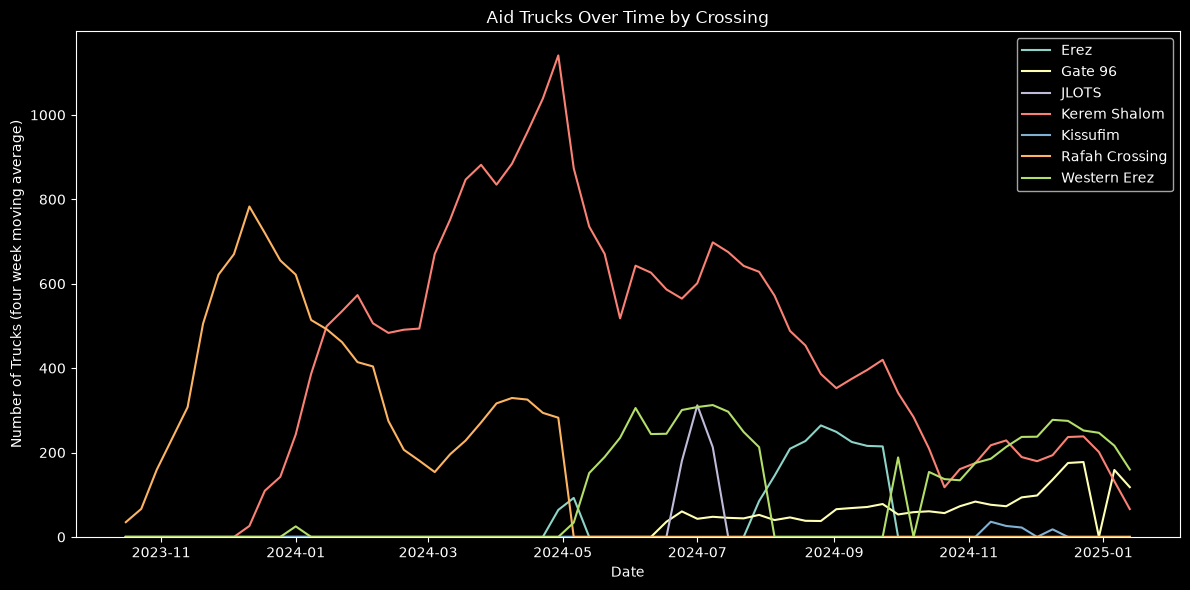

In [108]:
df = con.execute("""
WITH weekly_trucks_per_crossing AS (
    SELECT
        crossing_name,
        SUM(number_of_trucks) AS sum_of_trucks,
        year,
        week_of_year
    FROM main_mart.aid_events
    GROUP BY crossing_id, crossing_name, year, week_of_year
    ORDER BY year, week_of_year
)

SELECT
    crossing_name,
    sum_of_trucks,
    AVG(sum_of_trucks) OVER (PARTITION BY crossing_name ORDER BY year, week_of_year ROWS BETWEEN 3 PRECEDING AND CURRENT ROW) AS ma_4w_trucks,
    year,
    week_of_year
FROM weekly_trucks_per_crossing
ORDER BY year, week_of_year
""").df()


df["week_start"] = pd.to_datetime(
    df["year"].astype(str) + "-W" + df["week_of_year"].astype(str) + "-1",
    format="%G-W%V-%u"
)

df_pivot = df.pivot(
    index="week_start",
    columns="crossing_name",
    values="ma_4w_trucks"
).fillna(0).sort_index()

plt.figure(figsize=(12,6))

for column in df_pivot.columns:
    plt.plot(df_pivot.index, df_pivot[column], label=column)

plt.ylim(0)
plt.xlabel("Date")
plt.ylabel("Number of Trucks (four week moving average)")
plt.title("Aid Trucks Over Time by Crossing")
plt.legend()
plt.tight_layout()
plt.show()

Initially, Rafah Crossing was the only active entry point, accounting for all aid deliveries at the start of the period. It ceased operations in May 2024 and has not featured in the data since.

Kerem Shalom has emerged as the most used crossing, first appearing in late 2023 and consistently handling the highest truck volumes throughout the conflict.

The Western Erez crossing operated sporadically, with extended gaps in activity, usage increased notably towards the end of 2024 and into 2025.

The Gate 96, Erez and Kissufim crossing each recorded some activity, but truck volumes through these remained low throughout the period.

JLOTS - a floating dock established by the United States, allegedly for maritime aid deliveries - appears to have seen minimal usage in July 2024 and no recorded activity since.

In [109]:
import folium

df = con.execute("""
    SELECT
        dc.crossing_name,
        dc.border_zone,
        dc.bordering_country,
        dc.latitude,
        dc.longitude,
        SUM(ae.number_of_trucks) AS sum_of_trucks
    FROM main_mart.aid_events ae
    INNER JOIN main.dim_crossing dc
    ON ae.crossing_id = dc.crossing_id
    GROUP BY dc.crossing_name, dc.border_zone, dc.bordering_country, dc.latitude, dc.longitude
""").df()

map = folium.Map(location=[31.4, 34.3], zoom_start=10)

# Markers with popups showing truck counts
for idx, row in df.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"{row['crossing_name']}<br>Trucks: {row['sum_of_trucks']}",
        tooltip=row['crossing_name']
    ).add_to(map)

# Add circles sized by truck count for visual emphasis
for idx, row in df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=row['sum_of_trucks'] / 500,
        popup=f"{row['crossing_name']}<br>Trucks: {row['sum_of_trucks']}",
        color='purple',
        fill=True,
        fillOpacity=0.5
    ).add_to(map)

map

The map above visualizes total aid truck volume across the seven border crossings into Gaza. The majority of aid entered though the bottom of the Gaza Strip, with Kerem Shalom delivering more than twice the volume of any other crossing at over 27,000 trucks and the nearby Rafah Crossing serving as a critical alternate route with over 11,000 trucks.

In the north, the Western Erez and Erez crossings saw a combined total of over 8000 trucks going into the Gaza Strip.

The Gaza Floating Pier (JLOTS) only saw the equivient of 638 trucks entering Gaza, while allegedly costing $320 million dollars to build and operate for the 90 days that is was open. This would work out to roughly half a million dollars per truck, providing the data is complete and accurate.

In [110]:
con.close()
